# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('loan_data.csv')

In [3]:
df.shape

(45000, 14)

In [5]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


# Age vs Loan Status

I grouped ages to see if younger or older people are more likely to get approved for a loan. 

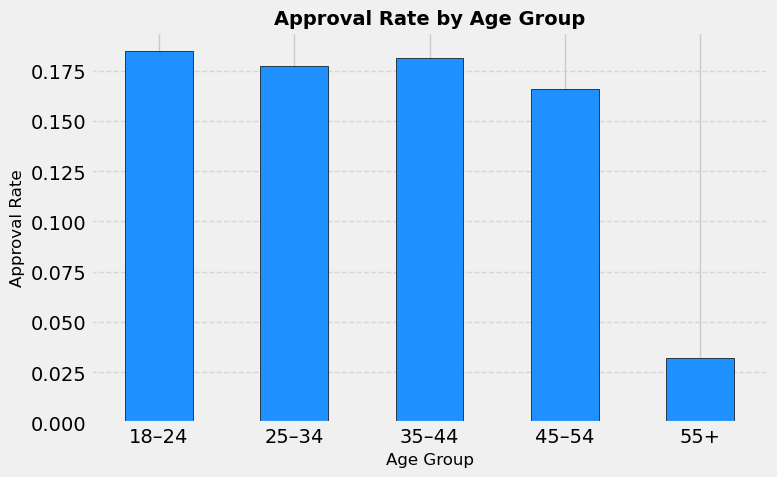

In [14]:
bins = [18, 25, 35, 45, 55, 100]
labels = ["18–24", "25–34", "35–44", "45–54", "55+"]

df["age_group"] = pd.cut(df["person_age"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
df.groupby("age_group")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Age Group", fontsize=14, weight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Most ages get approved at about the same rate but it drops a lot for people over 55.

# Gender vs Loan Status

I’m just checking to see if approval rates are different for men and women. If there’s a big difference without a good reason, that could be a fairness issue.

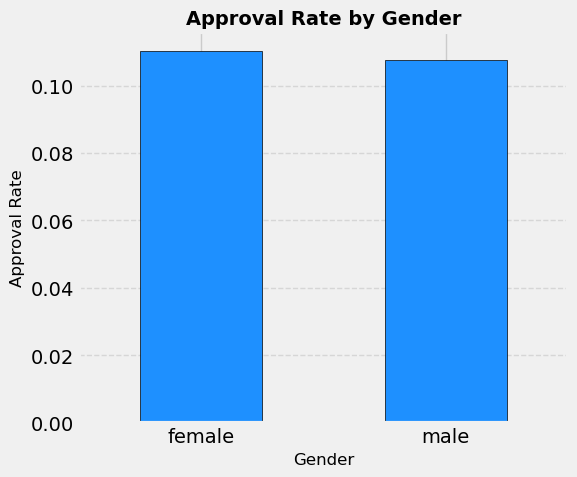

In [16]:
plt.figure(figsize=(6,5))
df.groupby("person_gender")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Gender", fontsize=14, weight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

They’re basically the same so gender doesn’t seem to make much difference here.

# Credit Score vs Loan Status

Now I’m checking how credit score affects loan approval. 

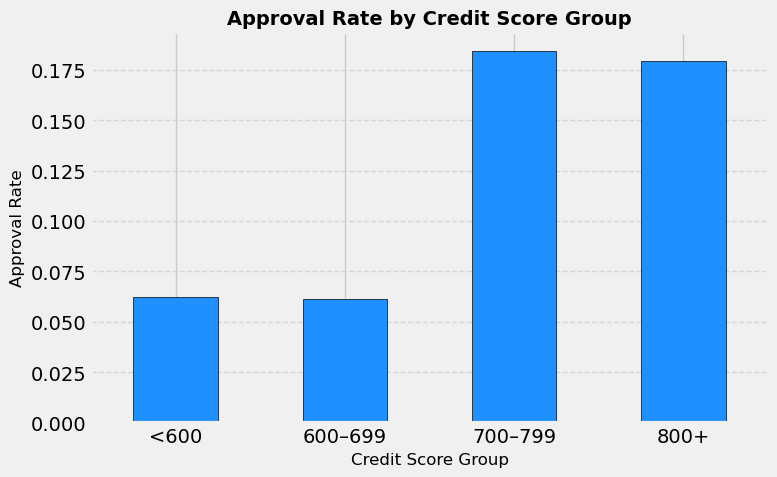

In [18]:
bins = [0, 600, 700, 800, 900]
labels = ["<600", "600–699", "700–799", "800+"]

df["credit_group"] = pd.cut(df["credit_score"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
df.groupby("credit_group")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Credit Score Group", fontsize=14, weight='bold')
plt.xlabel("Credit Score Group", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

The graph shows that people with higher credit scores get approved way more often. Once your score hits around 700, your chances of getting approved go up a lot.

# Previous Defaults vs Loan Status

I’m checking if people who’ve had a loan default before are less likely to get approved.

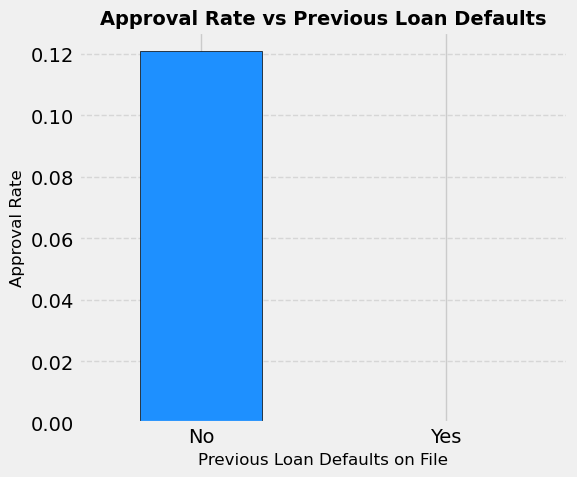

In [20]:
plt.figure(figsize=(6,5))
df.groupby("previous_loan_defaults_on_file")["loan_status"].mean().plot(
    kind="bar", color="dodgerblue", edgecolor="black"
)

plt.title("Approval Rate vs Previous Loan Defaults", fontsize=14, weight='bold')
plt.xlabel("Previous Loan Defaults on File", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

It shows that people who haven’t defaulted before get approved way more often while anyone with a past default pretty much doesn’t get approved.

# Loan Percent of Income vs Loan Status

Here I’m seeing if asking for a loan that’s a big chunk of your income hurts your chances.

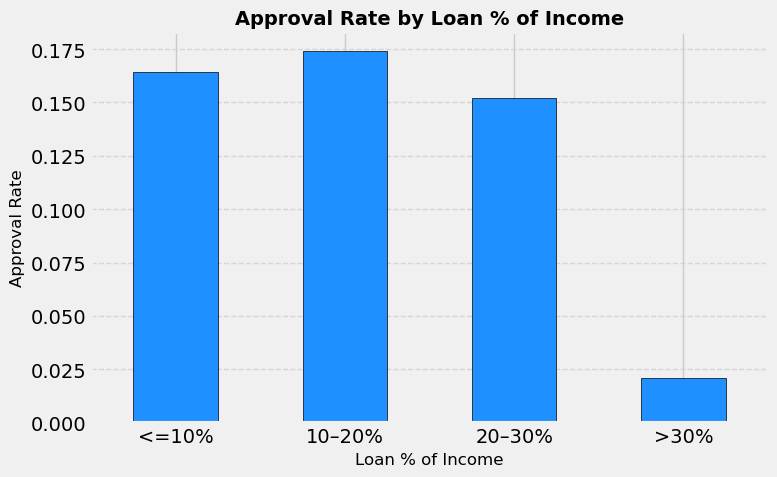

In [22]:
bins = [0.0, 0.1, 0.2, 0.3, 1.0]
labels = ["<=10%", "10–20%", "20–30%", ">30%"]

df["loan_pct_group"] = pd.cut(df["loan_percent_income"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
df.groupby("loan_pct_group")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Loan % of Income", fontsize=14, weight='bold')
plt.xlabel("Loan % of Income", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

It shows that people asking for smaller loans compared to their income get approved way more often, while those trying to borrow over 30% of their income barely get approved.

# Credit History Length vs Loan Status

I’m checking if people with a longer credit history get approved more.

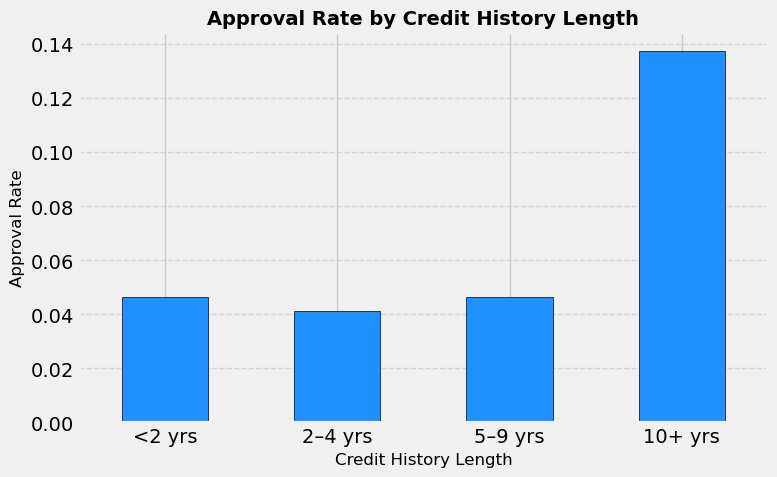

In [24]:
bins = [0, 2, 5, 10, 50]
labels = ["<2 yrs", "2–4 yrs", "5–9 yrs", "10+ yrs"]

df["hist_len_group"] = pd.cut(df["cb_person_cred_hist_length"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
df.groupby("hist_len_group")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Credit History Length", fontsize=14, weight='bold')
plt.xlabel("Credit History Length", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

This graph shows that people with longer credit histories, especially over 10 years, have much higher loan approval rates compared to those with shorter credit histories.

# Income vs Loan Status

Quick check to see if higher income is linked to higher approval rates.

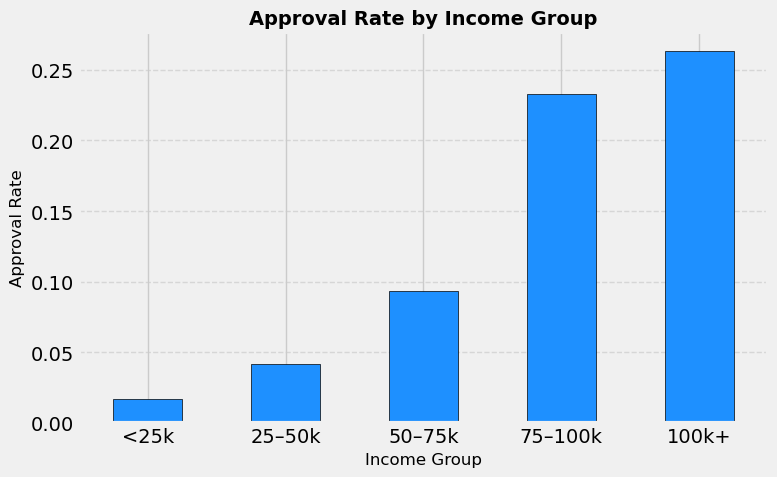

In [26]:
bins = [0, 25000, 50000, 75000, 100000, 1000000]
labels = ["<25k", "25–50k", "50–75k", "75–100k", "100k+"]

df["income_group"] = pd.cut(df["person_income"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(8,5))
df.groupby("income_group")["loan_status"].mean().plot(kind="bar", color="dodgerblue", edgecolor="black")

plt.title("Approval Rate by Income Group", fontsize=14, weight='bold')
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Approval Rate", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

This graph shows that higher income people get approved way more often than lower income ones.

# Which features seem to drive the model’s decision to grant a loan?

The main things that affect loan approval seem to be credit score, income, loan percent of income, credit history, and past defaults. People with high credit scores, good income, smaller loan amounts, and long credit histories get approved way more often, while anyone with a past default usually doesn’t. Makes sense since those all show how financially reliable someone is.

# Which features seem unrelated?

From the charts, age and gender don’t seem to matter much for loan approval. Most age groups had similar approval rates, with just a small drop for people over 55. Men and women also had almost the same rates, so it looks like the model isn’t really using those features, which is good for fairness.

# Should the financial institution be concerned about potential legal trouble?

Yeah, the company should still be careful. Even if age and gender don’t make a big difference, they’re protected traits, so using them in a model could cause legal issues. If the model includes them, it might come off as discrimination. It’s better to focus on financial stuff like credit score, income, and payment history so decisions are based on money, not personal details.